In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [5]:
# ==========================================
# Step 1: Data Validation and Loading
# ==========================================
# Load the dataset
file_path = '/kaggle/input/cleans/cleaned_comments.csv' 
try:
    df = pd.read_csv(file_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: {file_path} not found. Please upload the file.")
    raise

# Report shape
print(f"Dataset contains {df.shape[0]} comments and {df.shape[1]} columns.")

Data loaded successfully.
Dataset contains 58 comments and 4 columns.


In [6]:
# ==========================================
# Step 2: Text to Vector Conversion (TF-IDF)
# ==========================================
def parse_tokens(x):
    """Helper to safely parse the stringified list of tokens."""
    if pd.isna(x):
        return ""
    if isinstance(x, str):
        try:
            # Convert string "['word', 'word']" to list ['word', 'word']
            tokens = ast.literal_eval(x)
            return ' '.join(tokens)
        except (ValueError, SyntaxError):
            # If eval fails, return raw string
            return x
    # If it's already a list
    return ' '.join(x)

# Prepare corpus
if 'cleaned_tokens' in df.columns:
    corpus = df['cleaned_tokens'].apply(parse_tokens).tolist()
elif 'cleaned_text' in df.columns:
    corpus = df['cleaned_text'].astype(str).tolist()
else:
    raise ValueError("Neither 'cleaned_tokens' nor 'cleaned_text' columns found.")

# TF-IDF Transformation
vectorizer = TfidfVectorizer(max_features=2000)
X = vectorizer.fit_transform(corpus)
print(f"TF-IDF Matrix Shape: {X.shape}")


TF-IDF Matrix Shape: (58, 398)



--- Step 3: K-Means Analysis ---
Elbow plot saved as 'elbow_plot.png'. Check this to choose optimal k.

Running K-Means with k=3...
Cluster 0: video, thanks, magnifique, hfrvr, duh, wow, zeb, interesting, journey, amazing
Cluster 1: bbc, earth, love, humanity, blessing, zebra, back, news, december, africa
Cluster 2: beautiful, nature, zebra, animal, great, know, migration, way, dont, always
K-Means PCA visualization saved as 'kmeans_pca.png'.


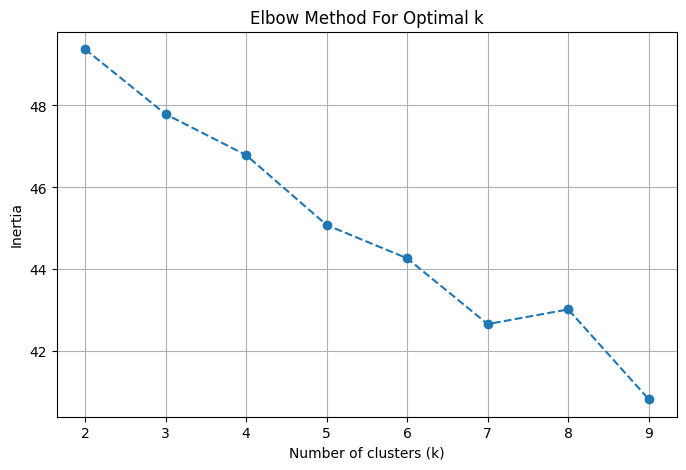

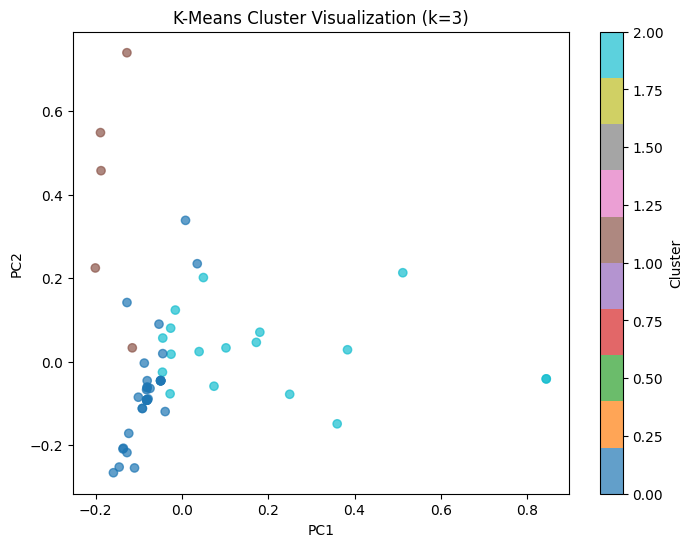

In [7]:
# ==========================================
# Step 3: K-Means Clustering
# ==========================================
print("\n--- Step 3: K-Means Analysis ---")

# A. Generate Elbow Plot
inertia = []
K_range = range(2, 10)  # Testing k from 2 to 9

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.savefig('elbow_plot.png')
print("Elbow plot saved as 'elbow_plot.png'. Check this to choose optimal k.")
# plt.show()

# B. Run K-Means and Analyze Clusters
# NOTE: Set optimal_k based on the elbow plot. 
# For this code, we default to 3 as a starting point.
optimal_k = 3 
print(f"\nRunning K-Means with k={optimal_k}...")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_label'] = kmeans.fit_predict(X)

# Print top terms per cluster
terms = vectorizer.get_feature_names_out()
for i in range(optimal_k):
    cluster_center = kmeans.cluster_centers_[i]
    # Get indices of top 10 terms with highest weights
    top_indices = cluster_center.argsort()[-10:][::-1]
    top_terms = [terms[idx] for idx in top_indices]
    print(f"Cluster {i}: {', '.join(top_terms)}")

# C. Visualize K-Means with PCA
X_pca = PCA(n_components=2).fit_transform(X.toarray())

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['kmeans_label'], cmap='tab10', alpha=0.7)
plt.title(f'K-Means Cluster Visualization (k={optimal_k})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Cluster')
plt.savefig('kmeans_pca.png')
print("K-Means PCA visualization saved as 'kmeans_pca.png'.")
# plt.show()


--- Step 4: DBSCAN Analysis ---
Testing DBSCAN parameters (min_samples=5)...

DBSCAN Tuning Results:
   eps  min_samples  clusters  noise_points
0  0.3            5         1            53
1  0.5            5         1            53
2  0.7            5         1            53
3  1.0            5         1            53
4  1.5            5         1            53

Auto-selected eps=0.3 for visualization.
DBSCAN PCA visualization saved as 'dbscan_pca.png'.


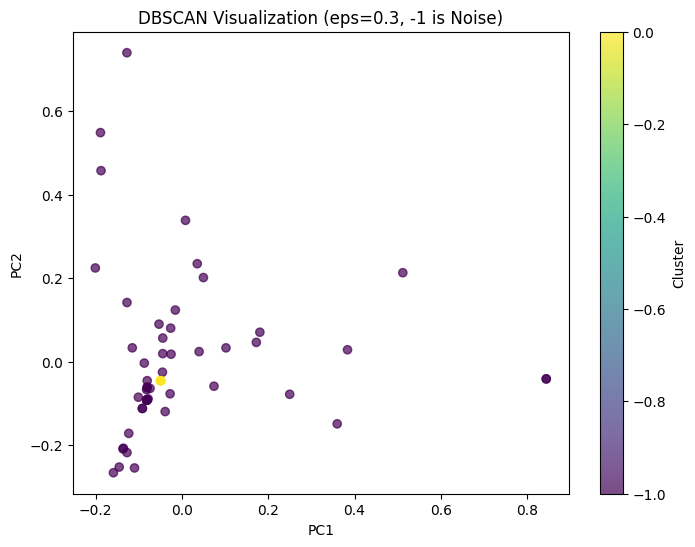

In [8]:
# ==========================================
# Step 4: Comparative Analysis with DBSCAN
# ==========================================
print("\n--- Step 4: DBSCAN Analysis ---")

# A. Scaling for DBSCAN
# DBSCAN requires scaled data, but preserving sparsity pattern (with_mean=False)
X_scaled = StandardScaler(with_mean=False).fit_transform(X)

# B. Parameter Tuning Loop
results = []
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5] # Extended range for sparse text data
min_samples_val = 5

print(f"Testing DBSCAN parameters (min_samples={min_samples_val})...")
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples_val)
    labels = dbscan.fit_predict(X_scaled)
    
    # Calculate stats
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    results.append({
        'eps': eps, 
        'min_samples': min_samples_val, 
        'clusters': n_clusters, 
        'noise_points': n_noise
    })

# Display tuning results
results_df = pd.DataFrame(results)
print("\nDBSCAN Tuning Results:")
print(results_df)

# C. Visualize Best DBSCAN Result
# NOTE: Update best_eps based on the table above.
# We select a value that yields >0 clusters if possible.
best_eps = 0.5 
# Heuristic to auto-select a potentially better eps if 0.5 fails:
valid_configs = results_df[results_df['clusters'] > 0]
if not valid_configs.empty:
    best_eps = valid_configs.iloc[0]['eps']
    print(f"\nAuto-selected eps={best_eps} for visualization.")
else:
    print(f"\nUsing default eps={best_eps} (Warning: might be all noise).")

dbscan_final = DBSCAN(eps=best_eps, min_samples=min_samples_val)
final_labels = dbscan_final.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
# Use the same PCA coordinates as before
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='viridis', alpha=0.7)
plt.title(f'DBSCAN Visualization (eps={best_eps}, -1 is Noise)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster')
plt.savefig('dbscan_pca.png')
print("DBSCAN PCA visualization saved as 'dbscan_pca.png'.")
# plt.show()